# Task 4 (Optional): Prioritize Potential Drug Target Genes

Using the perturbation results from Task 3, rank the 12 ALS target genes by how
effectively their perturbation shifts sALS cells toward the healthy (PN) state.

## Composite scoring

Task 3 established that no individual metric produces a strong or consistent
signal. To maximize sensitivity we combine two complementary metrics into a
single composite score:

1. **Axis projection** (`proj_df`) — fraction of the sALS→PN centroid distance
   recovered by the perturbed sALS centroid. Captures global, direction-specific
   movement in the embedding.
2. **KNN neighborhood shift** (`knn_df`) — change in the fraction of sALS
   cells' K=20 nearest neighbors that are PN cells. Captures local, cell-level
   movement regardless of overall direction.

Each metric is z-scored across all (gene × direction × cell type) observations
so neither dominates due to scale differences. The two z-scores are averaged to
form the composite, which is then averaged across cell types. For each gene we
report only the best-performing perturbation direction (knockup or knockdown).

## Important caveat

As established in Task 3, the GeneFormer embedding does not strongly separate
sALS from PN cells (silhouette ≈ 0.07). Both metrics are therefore operating
near the noise floor, and the rankings below reflect weak, inconsistent signals
rather than confident biological predictions. The composite score and rankings
should be treated as **exploratory hypotheses** to be validated experimentally
or re-evaluated after disease-state fine-tuning of the model.



In [1]:
%load_ext autoreload
%autoreload 2

import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import zscore

RESULTS_DIR = pathlib.Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)



In [2]:
# Load pre-computed metric DataFrames saved at the end of Task 3
proj_df = pd.read_csv("../data/proj_df.csv")
knn_df  = pd.read_csv("../data/knn_df.csv")



In [3]:
# Build composite score: z-score each metric, average, then mean across cell types.
# Select the best direction per gene.
merged = proj_df.merge(knn_df, on=["gene", "direction", "celltype"])

merged["z_axis"] = zscore(merged["axis_proj"])
merged["z_knn"]  = zscore(merged["delta_pn_frac"])
merged["composite"] = (merged["z_axis"] + merged["z_knn"]) / 2

gene_dir_scores = (
    merged.groupby(["gene", "direction"])["composite"]
    .mean()
    .reset_index()
)

best = (
    gene_dir_scores
    .loc[gene_dir_scores.groupby("gene")["composite"].idxmax()]
    .sort_values("composite", ascending=False)
    .reset_index(drop=True)
)
best["rank"] = best.index + 1
print(best[["rank", "gene", "direction", "composite"]].to_string(index=False))



 rank     gene direction  composite
    1    DCTN1        up   1.185617
    2   SREBF2        up   1.105131
    3    LYNX1        up   0.583100
    4     NEFH        up   0.520528
    5  DYNC1H1        up   0.362313
    6    MYT1L        up   0.203361
    7     TBR1        up  -0.001470
    8    TTC14      down  -0.028611
    9    KIF5A        up  -0.059890
   10     REST      down  -0.123351
   11 HSP90AA1      down  -0.152718
   12   TUBA4A      down  -0.161626


## Plot 1: Drug target ranking

Horizontal bar chart of the composite rescue score for each gene's best
perturbation direction. Red bars indicate a positive composite score (net
movement toward PN across both metrics); blue bars indicate net movement away.

Genes are ranked top-to-bottom from most to least promising. The magnitude of
the bars is small by design — reflecting the weak signal established in Task 3
— but the relative ordering provides a starting point for prioritization.



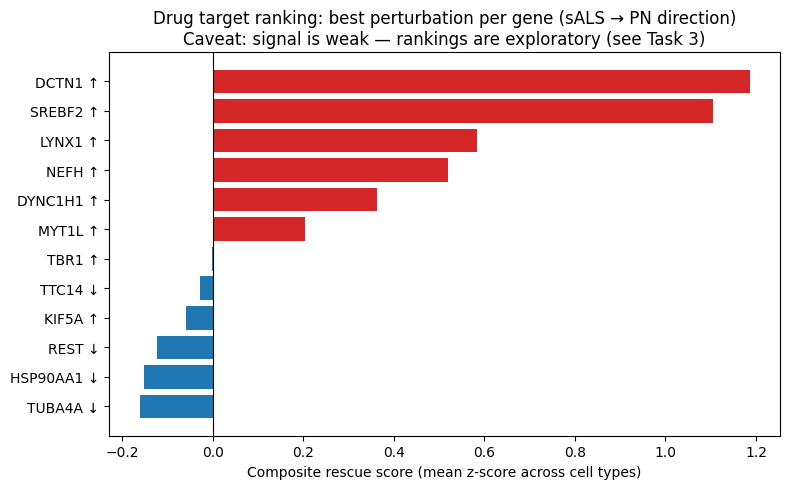

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = best["gene"] + " " + best["direction"].map({"up": "↑", "down": "↓"})
colors = ["#d62728" if s > 0 else "#1f77b4" for s in best["composite"]]
ax.barh(labels, best["composite"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.invert_yaxis()
ax.set_xlabel("Composite rescue score (mean z-score across cell types)")
ax.set_title(
    "Drug target ranking: best perturbation per gene (sALS → PN direction)\n"
    "Caveat: signal is weak — rankings are exploratory (see Task 3)"
)
plt.tight_layout()
plt.savefig("../results/drug_target_ranking.png", dpi=150, bbox_inches="tight")
plt.show()



## Plot 2: Metric agreement scatter

Each point is a (gene, direction) pair, positioned by its mean z-scored axis
projection (x) vs. mean z-scored KNN shift (y) across cell types. Triangles
pointing up = knockup; pointing down = knockdown.

Points near the dashed diagonal are supported by **both** metrics and should be
given more weight. Points far off the diagonal are driven by only one metric —
the composite score for those genes is less reliable.

The scatter of points across all four quadrants (no clear clustering along the
diagonal) is consistent with the Task 3 finding that both metrics are largely
measuring noise in the current embedding.



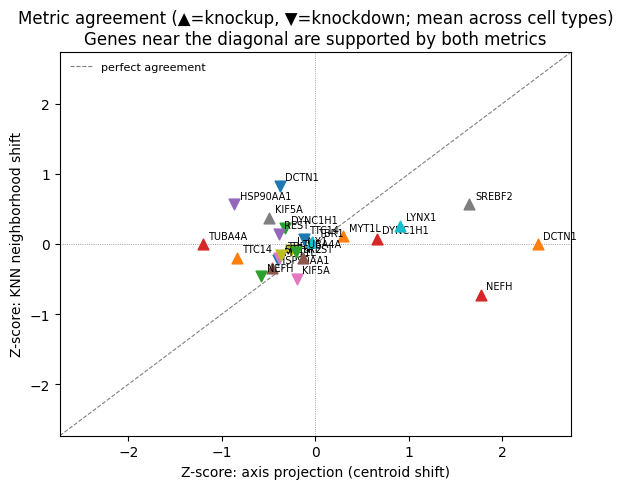

In [6]:
summary = merged.groupby(["gene", "direction"])[["z_axis", "z_knn"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 5))
for _, row in summary.iterrows():
    marker = "^" if row["direction"] == "up" else "v"
    ax.scatter(row["z_axis"], row["z_knn"], marker=marker, s=60, zorder=3)
    ax.annotate(row["gene"], (row["z_axis"], row["z_knn"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")

lim = max(abs(summary[["z_axis", "z_knn"]].values.ravel())) * 1.15
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.axhline(0, color="gray", lw=0.6, linestyle=":")
ax.axvline(0, color="gray", lw=0.6, linestyle=":")
ax.plot([-lim, lim], [-lim, lim], color="gray", lw=0.8,
        linestyle="--", label="perfect agreement")
ax.set_xlabel("Z-score: axis projection (centroid shift)")
ax.set_ylabel("Z-score: KNN neighborhood shift")
ax.set_title("Metric agreement (▲=knockup, ▼=knockdown; mean across cell types)\nGenes near the diagonal are supported by both metrics")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig("../results/drug_target_metric_agreement.png", dpi=150, bbox_inches="tight")
plt.show()
